In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import processing_fun
importlib.reload(processing_fun)

from utils import OperonArgs


Reading from configuration file: conf/Av_0.ini

Reading from selection file: conf/selection_0.ini

All model lengths:
[ 5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]

Equation requested:
(0.036547 + (1.000039 * sqrt(((1.089320 * X21) / (sqrt(1 + (0.082818 * X20) ^ 2))))))


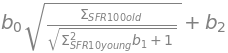


Latex version:
b_{0} \sqrt{\frac{\Sigma_{SFR100old}}{\sqrt{\Sigma_{SFR10young}^{2} b_{1} + 1}}} + b_{2}

Number of parameters: 3
Values: [1.0437456436397, 0.006858821124, 0.036547]


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Model Length', ylabel='RMSE'>)

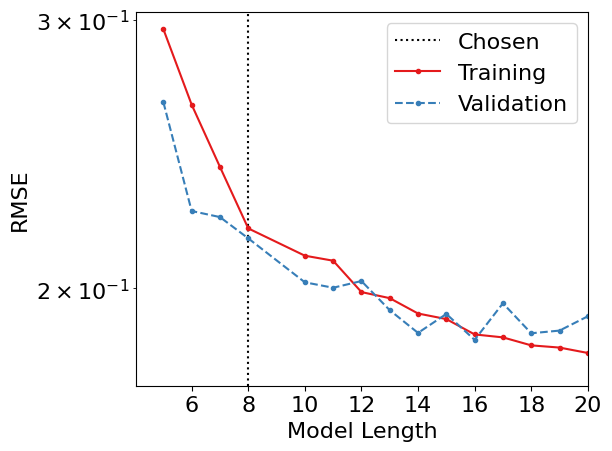

In [4]:
ini_file = 'conf/Av_0.ini'; ilen=8
importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='RMSE')


Reading from configuration file: conf/B0_0.ini

Reading from selection file: conf/selection_1.ini

All model lengths:
[ 5  6  7  8  9 10 11 12 14 15 17 18 20 21 22 23 24]

Equation requested:
(2.366002 + (1.000001 * ((0.003349 * X2) - ((-0.000768) * X3))))


100%|██████████| 17/17 [00:00<00:00, 152.35it/s]


Latex version:
B_{1} b_{0} + B_{2} b_{1} + b_{2}

Number of parameters: 3
Values: [0.003349003349, 0.000768000768, 2.366002]


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Model Length', ylabel='R2'>)

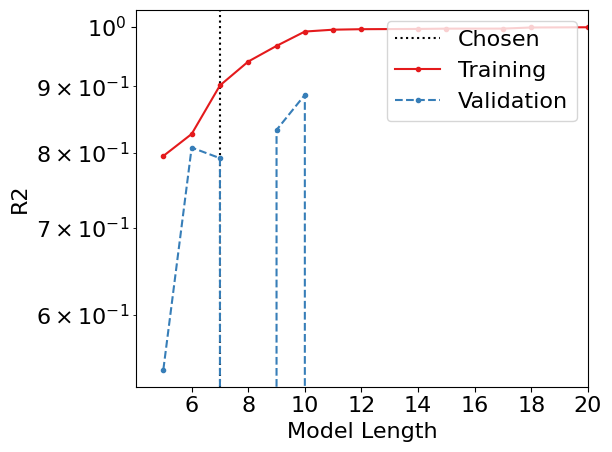

In [10]:
ini_file = 'conf/B0_0.ini'; ilen=7
importlib.reload(processing_fun)
processing_fun.plot_pareto(ini_file, ilen=ilen, yvar='R2')


Reading from configuration file: conf/Av_0.ini
Input columns: Index(['logMstar[logMsun]', 'logMgas[logMsun]', 'SFR[Msun/yr]',
       'SFR_compact[Msun/yr]', 'Zgas[mass_fraction]', 'rstar[kpc]',
       'rgas[kpc]', 'Mdust_RKC[Msun]', 'rgas_SF[kpc]', 'Age[yr]',
       'SFR_100Myr[Msun]', 'SFR_10Myr[Msun]', 'rstar_old[kpc]',
       'rstar_young[kpc]', 'Mmetals(<rstar_young)[Msun]',
       'Mmetals(<rstar_old)[Msun]', 'Mmetals(<rgas_SF)[Msun]', 'Mstar[Msun]',
       'Mgas[Msun]', 'Sigma_SFR_10_young[Msun/yr/kpc^2]',
       'Sigma_SFR_100_old[Msun/yr/kpc^2]', 'Sigma_SFR_all[Msun/yr/kpc^2]',
       'Sigma_gas_rgas[Msun/kpc^2]', 'Sigma_gas_rSF[Msun/kpc^2]',
       'burstiness_ks_young', 'burstiness_ks_old', 'burstiness_ks_all',
       'rstar_old_over_rgas', 'rstar_old_over_rSF', 'rstar_young_over_rgas',
       'rstar_young_over_rSF', 'rstar_old_over_rstar_young',
       'Sigma_dust_rgas[Msun/kpc^2]'],
      dtype='object')
(1343, 33) (1343,)
(688, 33) (688,)


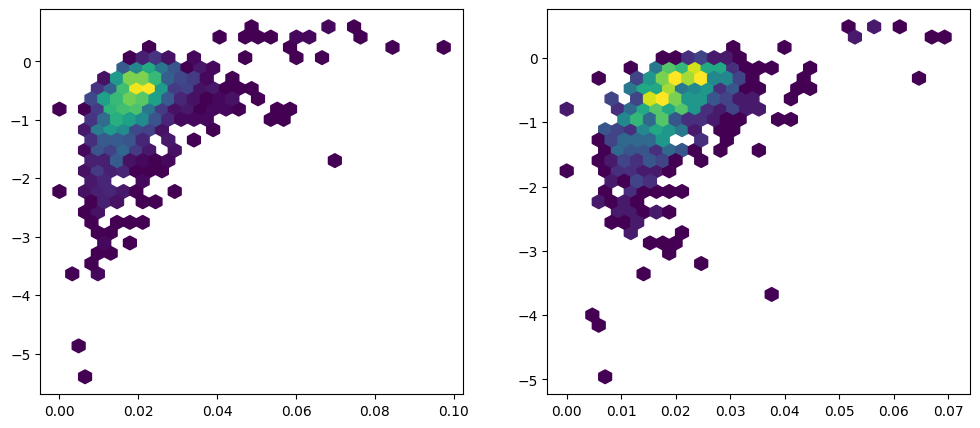

In [11]:
ini_file = 'conf/Av_0.ini'

args = OperonArgs(ini_file)

df_train = pd.read_csv(args.train_file, sep='\t')
df_val = pd.read_csv(args.val_file, sep='\t')

in_cols = df_train.columns.drop(['galaxy_id', 'los', 'dust_mixture', args.target_name])
print('Input columns:', in_cols)

X_train = df_train[in_cols].values
y_train = df_train[args.target_name].values
X_val = df_val[in_cols].values
y_val = df_val[args.target_name].values

y_train = np.log10(y_train)
y_val = np.log10(y_val)

i = 4
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
gridsize = 30
axs[0].hexbin(X_train[:, i], y_train, mincnt=1, gridsize=gridsize, label='Train')
axs[1].hexbin(X_val[:, i], y_val, mincnt=1, gridsize=gridsize, label='Validation')

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)